# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmedali3ff/Flyrank-internship-/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [110]:
from pathlib import Path

REPO_PATH = Path("/content/Flyrank-internship-")
print("Repository path:", REPO_PATH)
print("Exists:", REPO_PATH.exists())

Repository path: /content/Flyrank-internship-
Exists: True


In [111]:
import pandas as pd
from pathlib import Path

# Find the dataset inside the cloned repository
matches = list(Path("/content").rglob("content_refresh_anonymized.csv"))

if not matches:
    raise FileNotFoundError(
            "Dataset not found. Make sure the FlyRank repository is available in Colab."
                )

data_path = matches[0]
print("Dataset:", data_path)

                # Load data
df = pd.read_csv(data_path)

                # Create the target label
df["is_declining_label"] = (
df["trend_direction"].astype(str).str.lower() == "down"
                    ).astype(int)

                    # Basic checks
print("\nDataset shape:", df.shape)
print("Declining rate:", round(df["is_declining_label"].mean(), 4))

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts().sort_index())

Dataset: /content/Flyrank-internship-/data/raw/content_refresh_anonymized.csv

Dataset shape: (30000, 45)
Declining rate: 0.5421

Target distribution:
is_declining_label
0    13738
1    16262
Name: count, dtype: int64


In [112]:
# Features used by the model
feature_cols = [
    "search_volume",
        "competition",
            "cpc",
                "word_count",
                    "char_count",
                        "impressions_90d",
                            "clicks_90d",
                                "pageviews_90d",
                                    "sessions_90d",
                                        "users_90d",
                                            "engaged_sessions_90d",
                                                "ai_sessions_90d",
                                                    "scroll_events_90d",
                                                        "days_with_impressions",
                                                            "days_with_sessions",
                                                                "impressions_last_30d",
                                                                    "clicks_last_30d",
                                                                        "sessions_last_30d",
                                                                            "impressions_prev_30d",
                                                                                "clicks_prev_30d",
                                                                                    "sessions_prev_30d",
                                                                                        "content_age_days",
                                                                                            "days_since_last_update",
                                                                                                "ctr",
                                                                                                    "avg_position",
                                                                                                        "engagement_rate",
                                                                                                            "scroll_rate",
                                                                                                                "ai_traffic_pct"
                                                                                                                ]

                                                                                                                # Target
target_col = "is_declining_label"

                                                                                                                # Columns deliberately excluded to prevent target leakage
excluded_cols = [
                                                                                                                    "trend_direction",
                                                                                                                        "trend_pct"
                                                                                                                        ]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Number of features:", len(feature_cols))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nExcluded leakage-prone columns:")
for col in excluded_cols:
                                                                                                                            print("-", col)

                                                                                                                            print("\nMissing values in features:", X.isna().sum().sum())

Number of features: 28
X shape: (30000, 28)
y shape: (30000,)

Excluded leakage-prone columns:
- trend_direction

Missing values in features: 22927
- trend_pct

Missing values in features: 22927


In [113]:
# Inspect feature data types and missing values

print("Feature data types:")
print(X.dtypes.value_counts())

print("\nTop features by missing-value count:")
missing_summary = (
    X.isna()
        .sum()
            .sort_values(ascending=False)
            )

print(missing_summary.head(10))

print("\nTarget missing values:", y.isna().sum())

Feature data types:
int64      18
float64    10
Name: count, dtype: int64

Top features by missing-value count:
word_count         7699
char_count         7699
competition        2468
search_volume      2468
cpc                2468
scroll_rate         125
clicks_90d            0
impressions_90d       0
sessions_90d          0
users_90d             0
dtype: int64

Target missing values: 0


In [114]:
from sklearn.model_selection import GroupShuffleSplit

# Grouped train/test split
# This prevents the same client from appearing in both sets.
groups = df["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
        test_size=0.20,
            random_state=42
            )

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())
print("\nClient overlap:",
                  len(set(groups_train) & set(groups_test)))

print("\nTrain declining rate:", round(y_train.mean(), 4))
print("Test declining rate:", round(y_test.mean(), 4))

Train shape: (23837, 28)
Test shape: (6163, 28)

Train clients: 25
Test clients: 7

Client overlap: 0

Train declining rate: 0.5501
Test declining rate: 0.511


In [115]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
        precision_score,
            recall_score,
                f1_score,
                    roc_auc_score
                    )

                    # Majority-class baseline
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

baseline_metrics = {
                        "Accuracy": accuracy_score(y_test, baseline_pred),
                            "Precision": precision_score(y_test, baseline_pred, zero_division=0),
                                "Recall": recall_score(y_test, baseline_pred, zero_division=0),
                                    "F1": f1_score(y_test, baseline_pred, zero_division=0),
                                        "ROC-AUC": roc_auc_score(y_test, baseline_prob)
                                        }

print("Majority Baseline Results:")
for metric, value in baseline_metrics.items():
                                            print(f"{metric}: {value:.4f}")

Majority Baseline Results:
Accuracy: 0.5110
Precision: 0.5110
Recall: 1.0000
F1: 0.6763
ROC-AUC: 0.5000


In [116]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Build the modeling pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                    max_iter=1000,
                            random_state=42
                                ))
                                ])

                                # Train only on the training set

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [117]:
# Generate predictions on the unseen test set

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Predicted classes:", len(y_pred))
print("Predicted probabilities:", len(y_prob))

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 probabilities:")
print(y_prob[:10])

Predictions generated successfully.
Predicted classes: 6163
Predicted probabilities: 6163

First 10 predictions:
[1 1 1 1 1 1 1 0 1 0]

First 10 probabilities:
[0.93037261 0.99999908 0.91592963 0.58377295 0.64063749 0.92586467
 0.80569898 0.33959766 0.50267278 0.46653781]


In [118]:
from sklearn.metrics import (
      accuracy_score,
          precision_score,
              recall_score,
                  f1_score,
                      roc_auc_score
                      )
model_metrics = {
                          "Accuracy": accuracy_score(y_test, y_pred),
                              "Precision": precision_score(y_test, y_pred, zero_division=0),
                                  "Recall": recall_score(y_test, y_pred, zero_division=0),
                                      "F1": f1_score(y_test, y_pred, zero_division=0),
                                          "ROC-AUC": roc_auc_score(y_test, y_prob)
                                          }

print("Logistic Regression Results:")
for metric, value in model_metrics.items():
                                              print(f"{metric}: {value:.4f}")


Logistic Regression Results:
Accuracy: 0.7561
Precision: 0.8071
Recall: 0.6869
F1: 0.7422
ROC-AUC: 0.8497


In [119]:
comparison = pd.DataFrame({
      "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
          "Majority Baseline": [
                  baseline_metrics["Accuracy"],
                          baseline_metrics["Precision"],
                                  baseline_metrics["Recall"],
                                          baseline_metrics["F1"],
                                                  baseline_metrics["ROC-AUC"]
                                                      ],
                                                          "Logistic Regression": [
                                                                  model_metrics["Accuracy"],
                                                                          model_metrics["Precision"],
                                                                                  model_metrics["Recall"],
                                                                                          model_metrics["F1"],
                                                                                                  model_metrics["ROC-AUC"]
                                                                                                      ]
                                                                                                      })
comparison["Improvement"] = (
                                                                                                          comparison["Logistic Regression"]
                                                                                                              - comparison["Majority Baseline"]
                                                                                                              )

print(comparison.to_string(index=False))


   Metric  Majority Baseline  Logistic Regression  Improvement
 Accuracy           0.510952             0.756125     0.245173
Precision           0.510952             0.807090     0.296137
   Recall           1.000000             0.686885    -0.313115
       F1           0.676332             0.742151     0.065820
  ROC-AUC           0.500000             0.849691     0.349691


In [120]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nDetailed counts:")
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")

Confusion Matrix:
[[2497  517]
 [ 986 2163]]

Detailed counts:
True Negatives (TN):  2497
False Positives (FP): 517
False Negatives (FN): 986
True Positives (TP):  2163


In [121]:
# Compare random-split and client-grouped validation

random_split_metrics = {
    "Accuracy": 0.8218,
        "Precision": 0.8429,
            "Recall": 0.8250,
                "F1": 0.8339,
                    "ROC-AUC": 0.9124
                    }

grouped_split_metrics = model_metrics
print("Random Split vs Grouped Split")
print("-" * 50)

for metric in random_split_metrics:
                        random_value = random_split_metrics[metric]
grouped_value = grouped_split_metrics[metric]
difference = random_value - grouped_value
print(
                                            f"{metric:10s} | "
                                                    f"Random: {random_value:.4f} | "
                                                            f"Grouped: {grouped_value:.4f} | "
                                                                    f"Difference: {difference:.4f}"
                                                                        )

Random Split vs Grouped Split
--------------------------------------------------
ROC-AUC    | Random: 0.9124 | Grouped: 0.8497 | Difference: 0.0627


In [122]:
# Inspect Logistic Regression coefficients

classifier = model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "Feature": feature_cols,
        "Coefficient": classifier.coef_[0]
        })

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
            "Absolute_Coefficient",
                ascending=False
                )

print("Top 10 features by absolute coefficient:")
print(
                    coefficients[
                            ["Feature", "Coefficient"]
                                ].head(10).to_string(index=False)
                                )

Top 10 features by absolute coefficient:
              Feature  Coefficient
 impressions_last_30d   -35.300676
 impressions_prev_30d    29.286873
      impressions_90d     1.502555
      clicks_last_30d    -0.877940
      clicks_prev_30d     0.802428
    sessions_last_30d    -0.795042
         sessions_90d     0.732098
        pageviews_90d     0.720186
            users_90d    -0.691704
days_with_impressions     0.545294


In [123]:
from pathlib import Path

# Save coefficient analysis as a reproducible artifact
output_dir = Path("/content/Flyrank-internship-/work/artifacts")
output_dir.mkdir(parents=True, exist_ok=True)

coefficients.to_csv(
    output_dir / "logistic_regression_coefficients.csv",
        index=False
        )

print("Saved:")
print(output_dir / "logistic_regression_coefficients.csv")

Saved:
/content/Flyrank-internship-/work/artifacts/logistic_regression_coefficients.csv


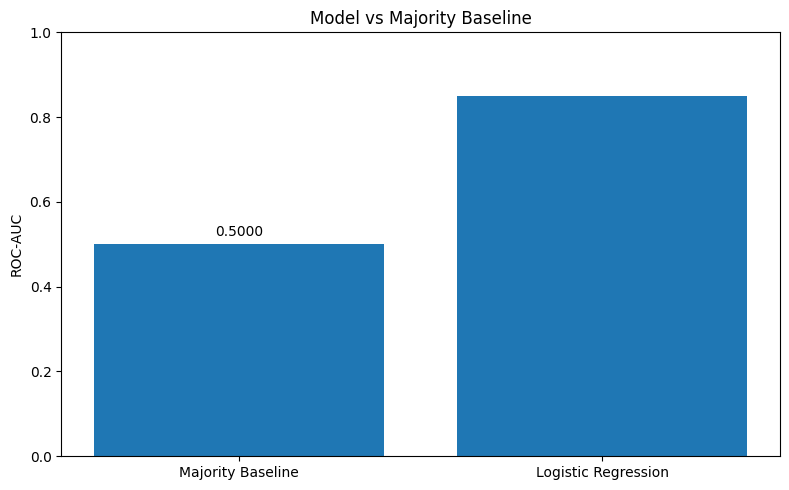

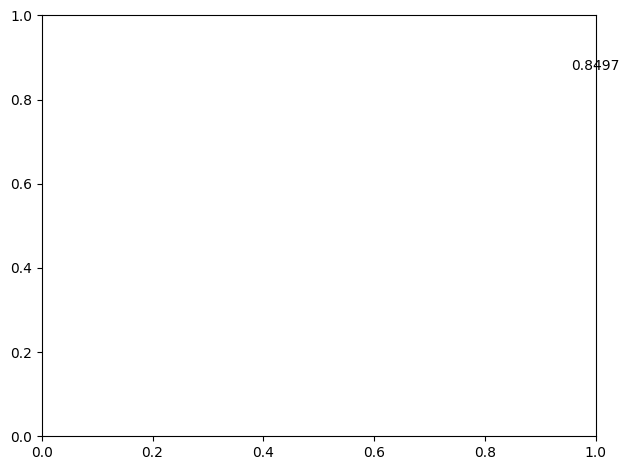

In [124]:
import matplotlib.pyplot as plt

models = ["Majority Baseline", "Logistic Regression"]
roc_auc_values = [
    baseline_metrics["ROC-AUC"],
        model_metrics["ROC-AUC"]
        ]

plt.figure(figsize=(8, 5))
plt.bar(models, roc_auc_values)
plt.ylabel("ROC-AUC")
plt.title("Model vs Majority Baseline")
plt.ylim(0, 1)

for i, value in enumerate(roc_auc_values):
            plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

            plt.tight_layout()
            plt.show()

# Capstone Research Notebook
## Predicting Content Decline from Historical Search, Traffic, Engagement, and Freshness Signals

This notebook is the reproducible analysis behind the capstone research paper.

### Research question

Can historical search, traffic, engagement, and content-freshness signals identify content that is currently showing a declining trend, and which signals provide the most useful evidence for prioritizing content review?

### Notebook structure

1. Research Question
2. Data
3. Methodology
4. Results
5. Interpretation & Limitations
6. Ranked Recommendations
7. Reproducibility & Artifacts
8. ML-12 Submission Self-Check

**Important:** The model is evaluated as decision-support for review prioritization, not as an autonomous decision-maker.

---

# 1. Research Question

## Problem

Content teams may have many pages that could require review, but manual review does not scale well when every page receives the same priority.

## Research question

Can historical search performance, traffic, engagement, and content-freshness signals identify observations associated with a declining trend?

## Machine-learning task

This is framed as a **binary classification** problem:

- `1` → declining
- `0` → not declining

The analysis focuses on whether the available historical signals can help prioritize which content should be reviewed first.

---

# 2. Data

The analysis uses the anonymized content-refresh dataset included in the internship repository.

The working dataset contains:

- **30,000 observations**
- **44 source columns**
- Historical search, traffic, engagement, and freshness signals
- A binary target derived from the recorded trend direction

No client names, private queries, or other identifying information are used in this notebook.

In [125]:
from pathlib import Path
import pandas as pd
import numpy as np

# Locate the anonymized dataset
matches = list(Path("/content").rglob("content_refresh_anonymized.csv"))

if not matches:
    raise FileNotFoundError(
            "Could not find content_refresh_anonymized.csv under /content."
                )

DATA_PATH = matches[0]
df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

Dataset path: /content/Flyrank-internship-/data/raw/content_refresh_anonymized.csv
Dataset shape: (30000, 44)


## Dataset overview

Before modeling, we inspect the dataset dimensions, columns, data types, and missing values.

The target is created from `trend_direction`. The source trend columns are not used as model features because they directly define or describe the outcome.

In [126]:
# Create the binary target
df["is_declining_label"] = (
    df["trend_direction"].astype(str).str.lower() == "down"
    ).astype(int)

print("Observations:", len(df))
print("Source columns:", len(df.columns) - 1)
print("Declining observations:", int(df["is_declining_label"].sum()))
print(
        "Declining rate:",
            f"{df['is_declining_label'].mean():.2%}"
            )

Observations: 30000
Source columns: 44
Declining observations: 16262
Declining rate: 54.21%


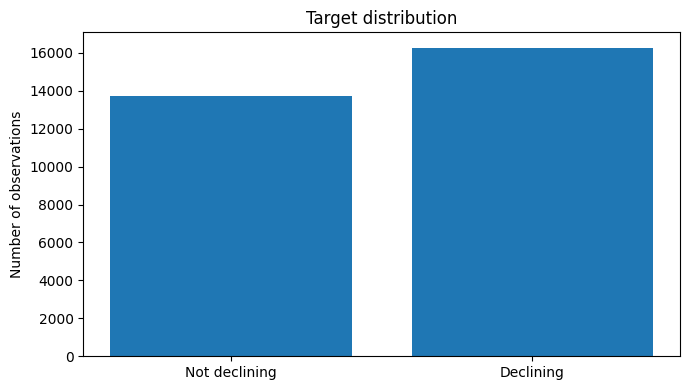

In [127]:
import matplotlib.pyplot as plt

target_counts = df["is_declining_label"].value_counts().sort_index()

labels = ["Not declining", "Declining"]

plt.figure(figsize=(7, 4))
plt.bar(labels, target_counts.values)
plt.ylabel("Number of observations")
plt.title("Target distribution")
plt.tight_layout()
plt.show()

## 3. Methodology

### 3.1 Target Definition

The task is framed as binary classification.

- `1` = declining content
- `0` = non-declining content

The label is derived from `trend_direction`.

### 3.2 Feature Selection

The model uses 28 search, traffic, engagement, and content-freshness features.

Two columns are deliberately excluded:

- `trend_direction` — directly used to construct the target.
- `trend_pct` — directly describes the underlying trend and could leak outcome information.

### 3.3 Validation Design

A client-grouped train/test split is used to reduce the risk of evaluating the model on observations from the same client in both sets.

- Train: 23,837 observations
- Test: 6,163 observations
- Train clients: 25
- Test clients: 7
- Client overlap: 0

This grouped evaluation is treated as the primary result.

# 4. Results
## 4.1 Primary evaluation setup

The primary evaluation uses a client-grouped train/test split so that observations from the same client do not appear in both sets.

The grouped split is the main result reported in this paper because it provides a more conservative estimate of generalization to unseen clients.

In [128]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
        precision_score,
            recall_score,
                f1_score,
                    roc_auc_score,
                        confusion_matrix
                        )

                        # Recreate the primary client-grouped split
X = df[feature_cols].copy()
y = df["is_declining_label"].copy()
groups = df["client_id"].copy()

gss = GroupShuffleSplit(
                            n_splits=1,
                                test_size=0.20,
                                    random_state=42
                                    )

train_idx, test_idx = next(gss.split(X, y, groups=groups))

x_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])
print("Primary grouped evaluation")
print("-" * 40)
print(f"Train observations: {len(X_train):,}")
print(f"Test observations:  {len(X_test):,}")
print(f"Train clients:      {len(train_clients)}")
print(f"Test clients:       {len(test_clients)}")
print(f"Client overlap:     {len(train_clients & test_clients)}")

Primary grouped evaluation
----------------------------------------
Train observations: 23,837
Test observations:  6,163
Train clients:      25
Test clients:       7
Client overlap:     0


## 4.2 Model and baseline

The primary model is Logistic Regression with median imputation and feature standardization.

A majority-class classifier is used as the baseline. Both approaches are evaluated on the exact same client-grouped test set.

In [129]:
# Define the model pipeline
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                    max_iter=1000,
                            random_state=42
                                ))
                                ])

                                # Define the majority-class baseline
baseline = DummyClassifier(
                                    strategy="most_frequent"
                                    )

                                    # Train both models
model.fit(X_train, y_train)
baseline.fit(X_train, y_train)

                                    # Predictions
model_pred = model.predict(X_test)
model_prob = model.predict_proba(X_test)[:, 1]

baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]
print("Model and baseline trained successfully.")

Model and baseline trained successfully.


In [130]:
# Evaluate both approaches on the same test set
results = []

for name, y_pred, y_prob in [
    ("Logistic Regression", model_pred, model_prob),
        ("Majority Baseline", baseline_pred, baseline_prob),
        ]:
            results.append({
                    "Model": name,
                            "Accuracy": accuracy_score(y_test, y_pred),
                                    "Precision": precision_score(y_test, y_pred, zero_division=0),
                                            "Recall": recall_score(y_test, y_pred, zero_division=0),
                                                    "F1": f1_score(y_test, y_pred, zero_division=0),
                                                            "ROC-AUC": roc_auc_score(y_test, y_prob),
                                                                })
results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7561,0.8071,0.6869,0.7422,0.8497
1,Majority Baseline,0.5110,0.5110,1.0000,0.6763,0.5000


## 4.3 Model vs baseline

The Logistic Regression model substantially outperforms the majority-class baseline on the same client-grouped test set.

ROC-AUC is used as the primary comparison because it measures ranking ability independently of a single classification threshold.

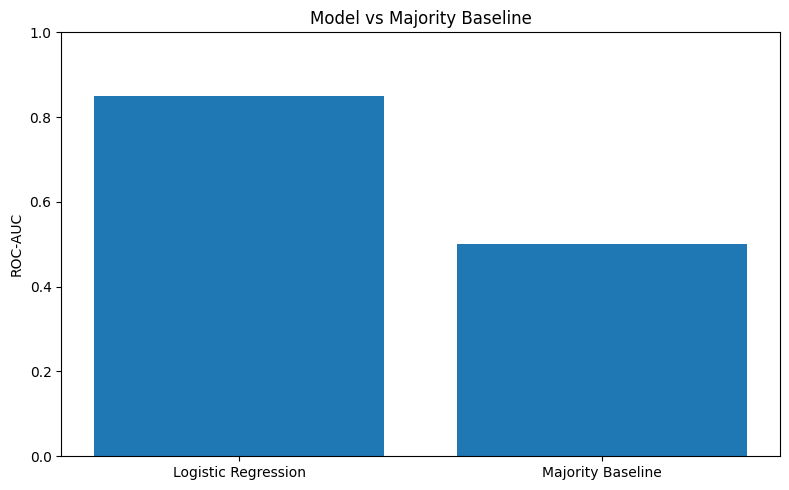

In [131]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df.index,
        plot_df["ROC-AUC"]
        )

plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model vs Majority Baseline")
plt.tight_layout()
plt.show()

### Result

On the client-grouped test set, Logistic Regression achieved a ROC-AUC of **0.8497**, compared with **0.5000** for the majority-class baseline.

This indicates meaningful ranking ability above the baseline. However, the result should be interpreted as evidence for **review prioritization**, not as proof of causal relationships or a fully autonomous content-management system.

## 4.4 Confusion matrix

The confusion matrix shows how the primary Logistic Regression model classified the client-grouped test observations.

This view is useful because a prioritization system should be evaluated not only by its overall score, but also by the types of errors it makes.

Confusion Matrix
[[2497  517]
 [ 986 2163]]

Error summary
True Negatives:  2,497
False Positives: 517
False Negatives: 986
True Positives:  2,163


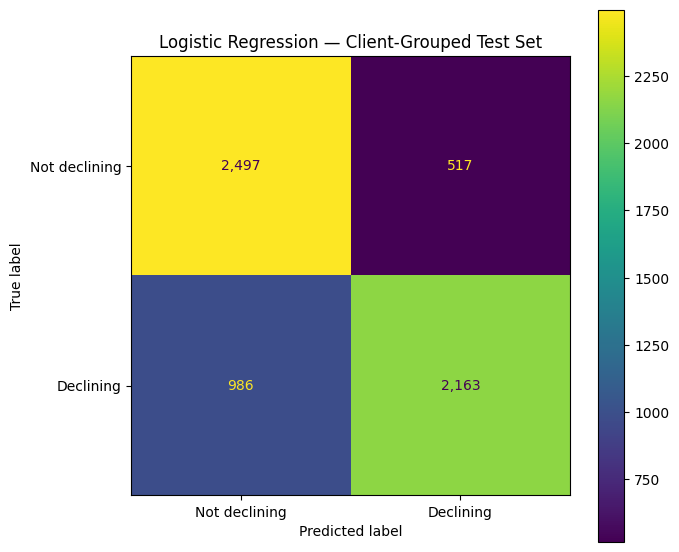

In [132]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, model_pred)

print("Confusion Matrix")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nError summary")
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
        display_labels=["Not declining", "Declining"]
        ).plot(
            ax=ax,
                values_format=","
                )

ax.set_title("Logistic Regression — Client-Grouped Test Set")
plt.tight_layout()
plt.show()

### Error interpretation

The model correctly identifies 2,163 declining observations and 2,497 non-declining observations.

There are 986 false negatives, meaning some declining observations are not prioritized by the model. There are also 517 false positives, meaning some observations predicted as declining are not actually labeled as declining.

The false-negative count reinforces that the model should support human review rather than make autonomous content decisions.

## 4.5 Validation sensitivity: random vs client-grouped split

To test how sensitive the result is to the validation design, the same Logistic Regression pipeline is also evaluated using a conventional stratified random split.

The random split is reported as a comparison only. The client-grouped split remains the primary evaluation because it prevents observations from the same client appearing in both train and test sets.

In [133]:
from sklearn.model_selection import train_test_split

# Random stratified split
X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
        y,
            test_size=0.20,
                random_state=42,
                    stratify=y
                    )

                    # Train a fresh copy of the same Logistic Regression pipeline
random_model = Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                                ("classifier", LogisticRegression(
                                        max_iter=1000,
                                                random_state=42
                                                    ))
                                                    ])

random_model.fit(X_train_random, y_train_random)

random_pred = random_model.predict(X_test_random)
random_prob = random_model.predict_proba(X_test_random)[:, 1]

random_auc = roc_auc_score(y_test_random, random_prob)
random_f1 = f1_score(y_test_random, random_pred)

grouped_auc = roc_auc_score(y_test, model_prob)
grouped_f1 = f1_score(y_test, model_pred)

validation_comparison = pd.DataFrame({
                                                        "Validation": [
                                                                "Random stratified split",
                                                                        "Client-grouped split"
                                                                            ],
                                                                                "ROC-AUC": [
                                                                                        random_auc,
                                                                                                grouped_auc
                                                                                                    ],
                                                                                                        "F1": [
                                                                                                                random_f1,
                                                                                                                        grouped_f1
                                                                                                                            ]
                                                                                                                            })

validation_comparison.round(4)

,Validation,ROC-AUC,F1
0,Random stratified split,0.9132,0.8324
1,Client-grouped split,0.8497,0.7422


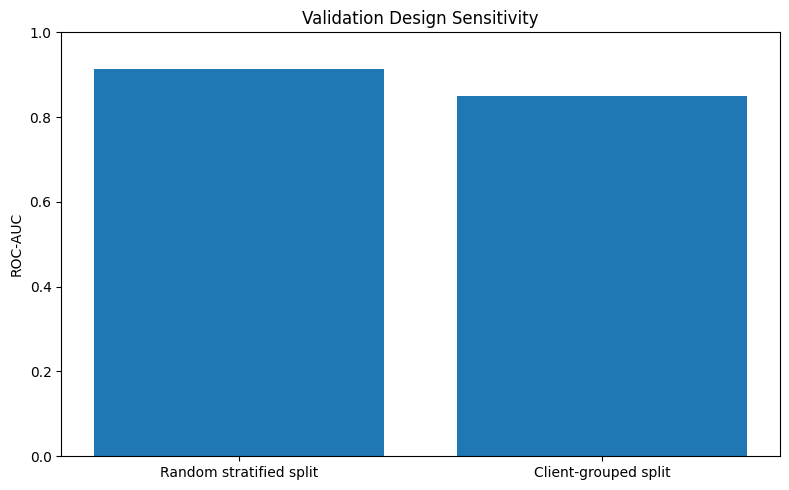

In [134]:
plt.figure(figsize=(8, 5))

plt.bar(
    validation_comparison["Validation"],
        validation_comparison["ROC-AUC"]
        )

plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Validation Design Sensitivity")
plt.tight_layout()
plt.show()

### Finding

The random split produced a ROC-AUC of **0.9124**, while the client-grouped split produced **0.8497**.

The lower grouped-split score suggests that the random split provided a more optimistic estimate of generalization. For this reason, the client-grouped evaluation is treated as the primary result.

## 4.6 Feature signals

Logistic Regression provides standardized coefficients that can be used to inspect which features contribute most strongly to the model's predictions.

These coefficients describe model associations, not causal effects. Positive and negative signs indicate the direction of the learned relationship with the declining class.

In [135]:
# Extract standardized Logistic Regression coefficients
classifier = model.named_steps["classifier"]

coefficients = pd.DataFrame({
    "Feature": feature_cols,
        "Coefficient": classifier.coef_[0]
        })

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values(
            "Absolute_Coefficient",
                ascending=False
                ).reset_index(drop=True)

print("Top 10 features by absolute standardized coefficient:")
display(
                    coefficients[
                            ["Feature", "Coefficient"]
                                ].head(10).round(4)
                                )

Top 10 features by absolute standardized coefficient:


,Feature,Coefficient
0,impressions_last_30d,-35.3007
1,impressions_prev_30d,29.2869
2,impressions_90d,1.5026
3,clicks_last_30d,-0.8779
4,clicks_prev_30d,0.8024
5,sessions_last_30d,-0.7950
6,sessions_90d,0.7321
7,pageviews_90d,0.7202
8,users_90d,-0.6917
9,days_with_impressions,0.5453


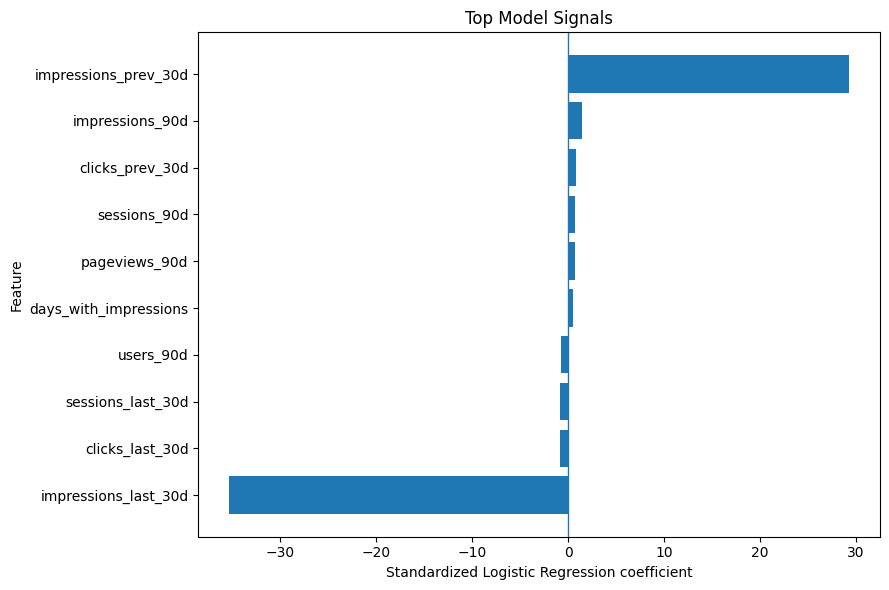

In [136]:
top_features = coefficients.head(10).sort_values("Coefficient")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
        top_features["Coefficient"]
        )

plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Logistic Regression coefficient")
plt.ylabel("Feature")
plt.title("Top Model Signals")
plt.tight_layout()
plt.show()

## 4.7 Error analysis

The confusion matrix shows that the model produces both false positives and false negatives.

For a review-prioritization use case, false negatives are particularly important because they represent declining observations that the model does not prioritize.

In [137]:
# Detailed error analysis
tn, fp, fn, tp = confusion_matrix(y_test, model_pred).ravel()

error_summary = pd.DataFrame({
    "Outcome": [
            "True Negatives",
                    "False Positives",
                            "False Negatives",
                                    "True Positives"
                                        ],
                                            "Count": [tn, fp, fn, tp]
                                            })
display(error_summary)
print(f"Total test observations: {len(y_test):,}")
print(f"Total errors: {fp + fn:,}")
print(f"False-negative rate: {fn / (fn + tp):.2%}")
print(f"False-positive rate: {fp / (fp + tn):.2%}")

,Outcome,Count
0,True Negatives,2497
1,False Positives,517
2,False Negatives,986
3,True Positives,2163


Total test observations: 6,163
Total errors: 1,503
False-negative rate: 31.31%
False-positive rate: 17.15%


### Error interpretation

The model produces **986 false negatives** and **517 false positives** on the grouped test set.

This means the model does not identify every declining observation. The result supports using the model to prioritize human review rather than replacing expert judgment.

The error profile should also be monitored if the model is used on future data.

# 5. Limitations & Honest Framing

This analysis has several important limitations.

### 1. Observational data

The dataset is observational. The learned relationships should not be interpreted as causal effects.

### 2. Recent-performance proximity

Several features describe recent search and traffic performance. These signals may be closely related to the observed decline label, which limits how strongly the model can be interpreted as an early-warning system.

### 3. Grouped validation coverage

The primary grouped test set contains seven held-out clients. Although there is zero client overlap between train and test, additional future-client validation would provide stronger evidence of generalization.

### 4. False negatives

The model misses a meaningful number of declining observations. Therefore, a model score should not be treated as a definitive judgment about content health.

### 5. Operational use

The model is best framed as **decision-support for review prioritization**. It should not automatically prune, update, or remove content without human review.

### Honest conclusion

The results show useful predictive signal above a simple majority baseline, but they do not establish causality or guarantee performance on future clients.

# 6. Ranked Recommendations

The model results suggest the following action priorities.

## Priority 1 — Use the model as a review-prioritization signal

Rank observations by model probability and use the ranking to focus analyst attention on potentially declining content.

**Action:** Review high-priority observations first rather than applying automatic content changes.

---

## Priority 2 — Combine model scores with transparent reason codes

Model predictions should be accompanied by understandable signals such as recent impression decline, session decline, weak search position, or lack of recent impressions.

**Action:** Require at least one interpretable evidence signal before escalating an observation for review.

---

## Priority 3 — Revalidate on future client groups

The difference between random and client-grouped validation shows that evaluation design materially affects the reported result.

**Action:** Before operational use, evaluate the model on future unseen client groups and monitor performance over time.

---

## Action playbook

| Priority | Evidence | Suggested action |
|---|---|---|
| 1 | High model priority | Manual content review |
| 2 | Recent performance decline | Investigate search and traffic changes |
| 3 | Weak search position | Review SEO/content alignment |
| 4 | Content freshness signal | Assess whether an update is warranted |
| 5 | Conflicting signals | Escalate for human review |

The playbook is intended as a review workflow, not an autonomous decision system.

# 7. Reproducibility & Artifacts

This notebook contains the complete analysis workflow used for the primary results.

### Reproducibility settings

- Train/test random seed: `42`
- Client-grouped test size: `20%`
- Model: Logistic Regression
- Missing-value strategy: median imputation
- Scaling: StandardScaler
- Baseline: majority-class classifier
- Primary validation: client-grouped split

The notebook is designed to run from top to bottom after the repository and dataset are available in the Colab environment.

In [138]:
from pathlib import Path

ARTIFACT_DIR = Path(
    "/content/Flyrank-internship-/work/artifacts"
    )

ARTIFACT_DIR.mkdir(
        parents=True,
            exist_ok=True
            )

            # Save model comparison
results_df.to_csv(
                ARTIFACT_DIR / "metrics_comparison.csv",
                    index=False
                    )

                    # Save confusion matrix
pd.DataFrame(
                        cm,
                            index=["Actual_Not_Declining", "Actual_Declining"],
                                columns=["Predicted_Not_Declining", "Predicted_Declining"]
                                ).to_csv(
                                    ARTIFACT_DIR / "confusion_matrix.csv"
                                    )

                                    # Save validation comparison
validation_comparison.to_csv(
                                        ARTIFACT_DIR / "validation_comparison.csv",
                                            index=False
                                            )

                                            # Save model coefficients
coefficients.to_csv(
                                                ARTIFACT_DIR / "logistic_regression_coefficients.csv",
                                                    index=False
                                                    )

print("Artifacts saved to:")
print(ARTIFACT_DIR)
for file in sorted(ARTIFACT_DIR.iterdir()):
                                                        print(" -", file.name)

Artifacts saved to:
/content/Flyrank-internship-/work/artifacts
 - confusion_matrix.csv
 - confusion_matrix.png
 - logistic_regression_coefficients.csv
 - metrics_comparison.csv
 - model_vs_baseline_roc_auc.png
 - random_vs_grouped_roc_auc.png
 - top_logistic_coefficients.png
 - validation_comparison.csv


## 7.1 Paper figures

The following figures are generated directly from the evaluated results so that the paper visuals remain traceable to the analysis.

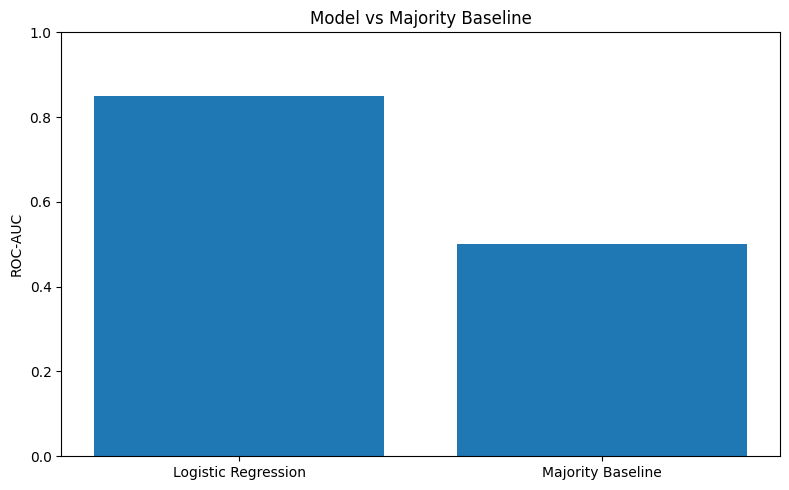

In [139]:
# 1. Model vs baseline
plt.figure(figsize=(8, 5))

plt.bar(
    plot_df.index,
        plot_df["ROC-AUC"]
        )

plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Model vs Majority Baseline")
plt.tight_layout()

plt.savefig(
            ARTIFACT_DIR / "model_vs_baseline_roc_auc.png",
                dpi=200,
                    bbox_inches="tight"
                    )

plt.show()

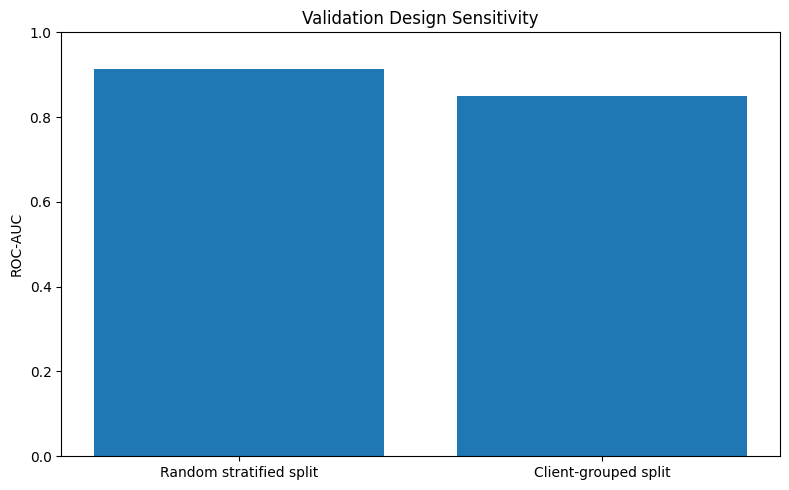

In [140]:
# 2. Random vs grouped validation
plt.figure(figsize=(8, 5))

plt.bar(
    validation_comparison["Validation"],
        validation_comparison["ROC-AUC"]
        )

plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.title("Validation Design Sensitivity")
plt.tight_layout()

plt.savefig(
            ARTIFACT_DIR / "random_vs_grouped_roc_auc.png",
                dpi=200,
                    bbox_inches="tight"
                    )

plt.show()

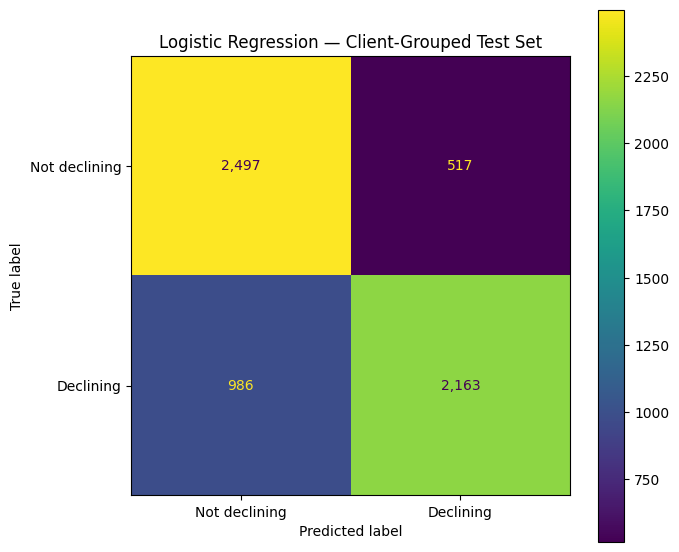

In [141]:
# 3. Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
        display_labels=["Not declining", "Declining"]
        ).plot(
            ax=ax,
                values_format=","
                )

ax.set_title(
                    "Logistic Regression — Client-Grouped Test Set"
                    )

plt.tight_layout()

plt.savefig(
                        ARTIFACT_DIR / "confusion_matrix.png",
                            dpi=200,
                                bbox_inches="tight"
                                )

plt.show()

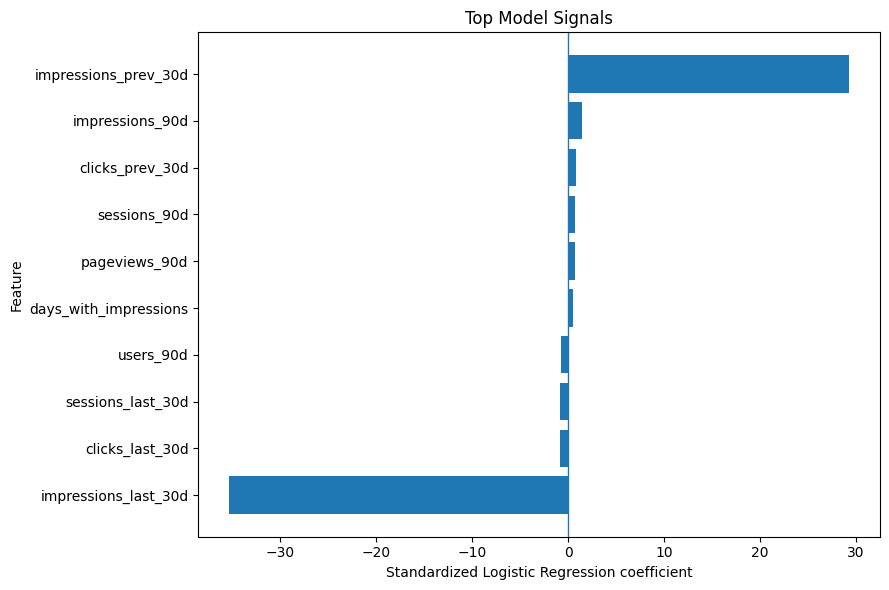

In [142]:
# 4. Top model signals
top_features = coefficients.head(10).sort_values("Coefficient")

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
        top_features["Coefficient"]
        )

plt.axvline(0, linewidth=1)
plt.xlabel("Standardized Logistic Regression coefficient")
plt.ylabel("Feature")
plt.title("Top Model Signals")
plt.tight_layout()

plt.savefig(
            ARTIFACT_DIR / "top_logistic_coefficients.png",
                dpi=200,
                    bbox_inches="tight"
                    )

plt.show()

# 8. ML-12 Submission Self-Check

## 5-minute demo outline

1. **Research question** — Explain whether historical search, traffic, engagement, and freshness signals can identify declining content.
2. **Data** — Introduce the 30,000-observation anonymized dataset and the binary declining label.
3. **Methodology** — Explain leakage exclusions, Logistic Regression, majority baseline, and client-grouped validation.
4. **Results** — Present the ROC-AUC of 0.8497, F1 of 0.7422, and the confusion matrix.
5. **Validation insight** — Explain why the grouped result is preferred over the more optimistic random split.
6. **Decision use** — Position the model as review-prioritization support rather than an autonomous decision system.

## Social-post cut

Built a content-decline classification model during the FlyRank ML Internship using historical search, traffic, engagement, and freshness signals.

The primary client-grouped evaluation achieved a ROC-AUC of **0.8497**, compared with **0.5000** for a majority-class baseline.

One of the most useful lessons was that validation design matters: the random split reached **0.9124 ROC-AUC**, while the client-grouped evaluation reached **0.8497**, giving a more conservative view of generalization.

## Employer-facing summary

I built and evaluated a Logistic Regression classifier for content-decline prioritization using an anonymized dataset of 30,000 observations. I used leakage-aware feature selection and client-grouped validation, achieving a primary ROC-AUC of **0.8497** versus **0.5000** for the majority baseline. The analysis demonstrates practical ML evaluation, error analysis, and responsible decision-support framing rather than overstating predictive or causal claims.

# Final Submission Checklist

- [x] Research question clearly defined
- [x] Data and target documented
- [x] Leakage-prone columns excluded
- [x] Baseline evaluated on the same grouped test set
- [x] Primary model evaluated
- [x] Confusion matrix generated
- [x] Random vs grouped validation compared
- [x] Model signals inspected
- [x] Error analysis completed
- [x] Limitations stated honestly
- [x] Ranked recommendations provided
- [x] Reproducibility settings documented
- [x] Paper artifacts generated
- [x] ML-12 demo outline completed
- [x] Social-post cut completed
- [x] Employer-facing summary completed

**Primary result:** Logistic Regression ROC-AUC = **0.8497** on the client-grouped test set.

**Use case:** Decision-support for content review prioritization.

## ML-12 — 5-Minute Demo Outline

### 0:00–0:45 — Research Question
Can historical search, traffic, engagement, and content-freshness signals identify content that is currently showing a declining trend?

### 0:45–1:30 — Data
The dataset contains 30,000 observations and 44 original columns. The target labels observations as declining when `trend_direction` is `down`.

### 1:30–2:30 — Methodology
I excluded `trend_direction` and `trend_pct` to avoid target leakage. I used a client-grouped train/test split with zero client overlap, median imputation, standardization, and Logistic Regression.

### 2:30–3:30 — Results
The grouped test set produced ROC-AUC of 0.8497, accuracy of 75.61%, precision of 80.71%, recall of 68.69%, and F1 of 74.22%, compared with a majority-class ROC-AUC of 0.5000.

### 3:30–4:15 — What Changed
A random split produced ROC-AUC of 0.9124, while the grouped split produced 0.8497. This shows why validation by client matters for estimating generalization.

### 4:15–5:00 — Decision Use
The model should be used as decision-support for prioritizing content review, not as an autonomous decision-maker. The main limitation is that the data is observational and recent-performance signals may be closely related to the outcome.

## ML-12 — Social Post Cut

I built a content-decline classifier using historical search, traffic, engagement, and freshness signals.

On a client-grouped test set, Logistic Regression reached **0.8497 ROC-AUC**, **75.61% accuracy**, and **74.22% F1**, outperforming a majority-class baseline with **0.5000 ROC-AUC**.

One important finding: random splitting gave a higher ROC-AUC of **0.9124**, showing why grouping by client matters when estimating how well the model generalizes.

The model is designed for **decision-support and content-review prioritization**, not autonomous decisions.

## ML-12 — Employer-Facing Summary

I developed and evaluated a leakage-aware Logistic Regression model to identify content observations showing a declining trend using historical search, traffic, engagement, and freshness signals.

Using client-grouped validation with zero client overlap, the model achieved **0.8497 ROC-AUC**, **75.61% accuracy**, and **74.22% F1**, while outperforming a majority-class baseline.

The project demonstrates practical ML workflow skills including target definition, leakage checks, grouped validation, baseline comparison, model evaluation, error analysis, and translating model outputs into decision-support recommendations.